# Final Project Notebook

DS 5001 Text as Data


# Metadata

- Full Name: Joseph Kaminetz
- Userid: emv3bc
- GitHub Repo URL: https://github.com/Joekam03/TextProject
- UVA Box URL:

# Overview

The goal of the final project is for you to create a **digital analytical edition** of a corpus using the tools, practices, and perspectives you’ve learning in this course. You will select a corpus that has already been digitized and transcribed, parse that into an F-compliant set of tables, and then generate and visualize the results of a series of fitted models. You will also draw some tentative conclusions regarding the linguistic, cultural, psychological, or historical features represented by your corpus. The point of the exercise is to have you work with a corpus through the entire pipeline from ingestion to interpretation. 

Specifically, you will acquire a collection of long-form texts and perform the following operations:

- **Convert** the collection from their source formats (F0) into a set of tables that conform to the Standard Text Analytic Data Model (F2).
- **Annotate** these tables with statistical and linguistic features using NLP libraries such as NLTK (F3).
- **Produce** a vector representation of the corpus to generate TFIDF values to add to the TOKEN (aka CORPUS) and VOCAB tables (F4).
- **Model** the annotated and vectorized model with tables and features derived from the application of unsupervised methods, including PCA, LDA, and word2vec (F5).
- **Explore** your results using statistical and visual methods.
- **Present** conclusions about patterns observed in the corpus by means of these operations.

When you are finished, you will make the results of your work available in GitHub (for code) and UVA Box (for data). You will submit to Gradescope (via Canvas) a PDF version of a Jupyter notebook that contains the information listed below.

# Some Details

- Please fill out your answers in each task below by editing the markdown cell. 
- Replace text that asks you to insert something with the thing, i.e. replace `(INSERT IMAGE HERE)` with an image element, e.g. `![](image.png)`.
- For URLs, just paste the raw URL directly into the text area. Don't worry about providing link labels using `[label](link)`.
- Please do not alter the structure of the document or cell, i.e. the bulleted lists. 
- You may add explanatory paragraphs below the bulleted lists.
- Please name your tables as they are named in each task below.
- Tasks are indicated by headers with point values in parentheses.

# Raw Data

## Source Description (1)

Provide a brief description of your source material, including its provenance and content. Tell us where you found it and what kind of content it contains.

This corpus contains plaintext national constitution documents from the GitHub repository `marcomorucci/Clustering-Constitutions`, specifically the `constitutions` directory. According to the Github repository, the constitutions were originally sourced from https://www.constituteproject.org/. Each source document is a country constitution identified by country name and year, such as `Afghanistan_2004.txt`. The content is legal and governmental prose: preambles, articles, chapters, sections, rights, duties, institutional rules, and amendment or enforcement provisions. 


## Source Features (1)

Add values for the following items. (Do this for all following bulleted lists.)

- Source URL: https://github.com/marcomorucci/Clustering-Constitutions/tree/master/constitutions
- UVA Box URL:
- Number of raw documents: 192
- Total size of raw documents (e.g. in MB): approximately 26.5 MB / 26,515,008 characters
- File format(s), e.g. XML, plaintext, etc.: plaintext `.txt`


## Source Document Structure (1)

Provide a brief description of the internal structure of each document. That, describe the typical elements found in document and their relation to each other. For example, a corpus of literary texts may be organized into chapters, paragraphs, sentences, and tokens.

The documents are parsed with the OHCO structure `doc -> div1 -> div2 -> unit -> para -> sent -> token`. The parser treats titles and parts as high-level `div1` divisions, chapters and sections as `div2` divisions when present, and articles as the main `unit` level. For constitutions without article headings, numbered provisions are used as the unit fallback. Paragraphs are created from non-heading text blocks, then split into sentences and word tokens. A variable OHCO structure like this was chosen because not every constitution has a defined hierarchical structure. Using a variable OHCO allows our analysis to capture whatever structure is present in the database. Codex helped me to automate the parsing of the data using the explained OHCO structure.


# Parsed and Annotated Data

Parse the raw data into the three core tables of your addition: the `LIB`, `CORPUS`, and `VOCAB` tables.

These tables will be stored as CSV files with header rows.

You may consider using `|` as a delimitter.

Provide the following information for each.

In [23]:
import re
import requests
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.feature_extraction import text
from sklearn.feature_extraction.text import CountVectorizer, ENGLISH_STOP_WORDS
from sklearn.decomposition import PCA
from sklearn.decomposition import LatentDirichletAllocation as LDA
from sklearn.manifold import TSNE as tsne
from gensim.parsing.porter import PorterStemmer
from gensim.models import word2vec

sns.set_theme(style='darkgrid')

# Get the file listing from the GitHub API
api_url = "https://api.github.com/repos/marcomorucci/Clustering-Constitutions/contents/constitutions"
response = requests.get(api_url, headers={"User-Agent": "FinalProject-OHCO"}, timeout=30)
response.raise_for_status()
files = sorted(response.json(), key=lambda x: x["name"])

constitutions = {}
lib_rows = []

for file_info in files:
    if not file_info["name"].endswith(".txt"):
        continue

    source_filename = file_info["name"]
    doc_id = source_filename.removesuffix(".txt")
    match = re.match(r"^(?P<country>.+)_(?P<year>\d{4})$", doc_id)
    country = match.group("country").replace("_", " ") if match else doc_id.replace("_", " ")
    year = int(match.group("year")) if match else np.nan

    raw_url = file_info["download_url"]
    raw_text = requests.get(raw_url, headers={"User-Agent": "FinalProject-OHCO"}, timeout=30).text
    constitutions[doc_id] = raw_text

    clean_lines = [line.strip() for line in raw_text.splitlines() if line.strip() and line.strip() != "Share"]
    lib_rows.append({
        "doc": doc_id,
        "country": country,
        "year": year,
        "source_filename": source_filename,
        "source_url": raw_url,
        "title_line": clean_lines[0] if clean_lines else "",
        "char_len": len(raw_text),
        "line_count": len(clean_lines),
    })

LIB = pd.DataFrame(lib_rows).set_index("doc").sort_index()

print(f"Loaded {len(constitutions)} constitutions")
print(f"Average document length: {LIB['char_len'].mean():,.0f} characters")
LIB.head()


Loaded 192 constitutions
Average document length: 138,099 characters


,country,year,source_filename,source_url,title_line,char_len,line_count
doc,,,,,,,
Afghanistan_2004,Afghanistan,2004,Afghanistan_2004.txt,https://raw.githubusercontent.com/marcomorucci...,Afghanistan 2004,66806,453
Albania_2008,Albania,2008,Albania_2008.txt,https://raw.githubusercontent.com/marcomorucci...,Albania 1998 (rev. 2008),86022,792
Algeria_2008,Algeria,2008,Algeria_2008.txt,https://raw.githubusercontent.com/marcomorucci...,Algeria 1963 (rev. 2008),66590,658
Andorra_1993,Andorra,1993,Andorra_1993.txt,https://raw.githubusercontent.com/marcomorucci...,Andorra 1993,55687,412
Angola_2010,Angola,2010,Angola_2010.txt,https://raw.githubusercontent.com/marcomorucci...,Angola 2010,175148,1393


In [24]:
# Middle OHCO parser: doc -> div1 -> div2 -> unit -> para -> sent -> token
# div1/div2 store flexible high-level legal divisions; unit is Article when present,
# otherwise numbered provisions for article-less constitutions.
HEADING_PATTERNS = {
    "preamble": re.compile(r"^\s*Preamble\b", re.I),
    "title": re.compile(r"^\s*TITLE\s+([IVXLCDM]+|\d+|[A-Z])\b[\.:]?\s*(.*)$", re.I),
    "part": re.compile(r"^\s*PART\s+([IVXLCDM]+|\d+|[A-Z]+)\b[\.:]?\s*(.*)$", re.I),
    "chapter": re.compile(r"^\s*CHAPTER\s+([IVXLCDM]+|\d+|[A-Z]+)\b[\.:]?\s*(.*)$", re.I),
    "section": re.compile(r"^\s*(SECTION|SEC\.?)\s+([IVXLCDM]+|\d+|[A-Z])\b[\.:]?\s*(.*)$", re.I),
    "article": re.compile(r"^\s*(ARTICLE|ART\.?)\s*[\(\[]?([IVXLCDM]+|\d+|[A-Z])\b[\)\]]?[\.:]?\s*(.*)$", re.I),
    "numbered": re.compile(r"^\s*(\d+(?:\.\d+)*)[\).]?\s+(.*)$"),
}
TOKEN_RE = re.compile(r"[A-Za-z]+(?:[-'][A-Za-z]+)*|\d+(?:\.\d+)*")
SENTENCE_SPLIT_RE = re.compile(r"(?<=[.!?])\s+")


def simple_pos(token_str):
    """Lightweight POS fallback so the CORPUS has pos and pos_group without NLTK data downloads."""
    if token_str.isdigit() or re.fullmatch(r"\d+(?:\.\d+)*", token_str):
        return "CD", "NUM"
    if token_str[:1].isupper():
        return "NNP", "NOUN"
    lower = token_str.lower()
    if lower.endswith("ly"):
        return "RB", "ADV"
    if lower.endswith(("ing", "ed")):
        return "VB", "VERB"
    if lower in {"the", "a", "an"}:
        return "DT", "DET"
    if lower in {"and", "or", "but", "nor"}:
        return "CC", "CONJ"
    if lower in {"in", "of", "to", "for", "with", "by", "from", "on", "at", "under", "over"}:
        return "IN", "ADP"
    return "NN", "NOUN"


def split_sentences(block):
    sentences = [s.strip() for s in SENTENCE_SPLIT_RE.split(block) if s.strip()]
    return sentences or [block.strip()]


def detect_heading(line):
    for heading_type in ["preamble", "title", "part", "chapter", "section", "article"]:
        match = HEADING_PATTERNS[heading_type].match(line)
        if match:
            if heading_type == "preamble":
                return {"type": heading_type, "label": "Preamble", "text": ""}
            if heading_type in {"section", "article"}:
                label = match.group(2)
                trailing = match.group(3).strip()
            else:
                label = match.group(1)
                trailing = match.group(2).strip()
            return {"type": heading_type, "label": label, "text": trailing}
    return None


def add_text_block(rows, doc_id, state, block):
    block = block.strip()
    if not block:
        return

    para_id = state["para"]
    state["para"] += 1

    for sent_id, sentence in enumerate(split_sentences(block)):
        # Keep token ids contiguous after removing leftover source UI artifacts.
        token_strings = [match.group(0) for match in TOKEN_RE.finditer(sentence) if match.group(0) != "Share"]
        for token_id, token_str in enumerate(token_strings):
            pos, pos_group = simple_pos(token_str)
            rows.append({
                "doc": doc_id,
                "div1": state["div1"],
                "div2": state["div2"],
                "unit": state["unit"],
                "para": para_id,
                "sent": sent_id,
                "token": token_id,
                "div1_type": state["div1_type"],
                "div1_label": state["div1_label"],
                "div2_type": state["div2_type"],
                "div2_label": state["div2_label"],
                "unit_type": state["unit_type"],
                "unit_label": state["unit_label"],
                "token_str": token_str,
                "term_str": token_str.lower(),
                "pos": pos,
                "pos_group": pos_group,
            })


def tokenize_ohco(text, doc_id):
    rows = []
    heading_counts = {key: 0 for key in HEADING_PATTERNS}
    raw_lines = [line.strip() for line in text.splitlines() if line.strip()]
    heading_counts["share_line"] = sum(1 for line in raw_lines if line == "Share")
    lines = [line for line in raw_lines if line != "Share"]

    # Prefer Article as the unit when a document uses articles at all; otherwise fall back to numbered provisions.
    has_articles = any(HEADING_PATTERNS["article"].match(line) for line in lines)
    state = {
        "div1": 0, "div2": 0, "unit": 0, "para": 0,
        "div1_type": "document", "div1_label": "whole_document",
        "div2_type": "body", "div2_label": "main_text",
        "unit_type": "intro", "unit_label": "intro",
    }

    for line_id, line in enumerate(lines):
        # First line is usually source metadata like "Afghanistan 2004".
        if line_id == 0 and re.search(r"\b\d{4}\b", line):
            continue

        heading = detect_heading(line)
        if heading:
            heading_counts[heading["type"]] += 1
            htype = heading["type"]

            if htype in {"title", "part"}:
                state["div1"] += 1
                state["div2"] = 0
                state["unit"] = 0
                state["para"] = 0
                state["div1_type"] = htype
                state["div1_label"] = heading["label"]
                state["div2_type"] = "body"
                state["div2_label"] = "main_text"
                state["unit_type"] = "intro"
                state["unit_label"] = "intro"
                add_text_block(rows, doc_id, state, heading["text"])
                continue

            if htype in {"chapter", "section"}:
                # If there is no title/part above it, let chapter be div1. Otherwise chapter/section become div2.
                if htype == "chapter" and state["div1_type"] not in {"title", "part"}:
                    state["div1"] += 1
                    state["div2"] = 0
                    state["div1_type"] = htype
                    state["div1_label"] = heading["label"]
                    state["div2_type"] = "body"
                    state["div2_label"] = "main_text"
                else:
                    state["div2"] += 1
                    state["div2_type"] = htype
                    state["div2_label"] = heading["label"]
                state["unit"] = 0
                state["para"] = 0
                state["unit_type"] = "intro"
                state["unit_label"] = "intro"
                add_text_block(rows, doc_id, state, heading["text"])
                continue

            if htype in {"article", "preamble"}:
                state["unit"] += 1
                state["para"] = 0
                state["unit_type"] = htype
                state["unit_label"] = heading["label"]
                add_text_block(rows, doc_id, state, heading["text"])
                continue

        numbered = HEADING_PATTERNS["numbered"].match(line)
        if numbered and not has_articles:
            heading_counts["numbered"] += 1
            state["unit"] += 1
            state["para"] = 0
            state["unit_type"] = "numbered"
            state["unit_label"] = numbered.group(1)
            add_text_block(rows, doc_id, state, numbered.group(2))
            continue

        add_text_block(rows, doc_id, state, line)

    return rows, heading_counts


ohco_list = []
coverage_rows = []
for doc_id, raw_text in constitutions.items():
    doc_rows, counts = tokenize_ohco(raw_text, doc_id)
    ohco_list.extend(doc_rows)
    coverage_rows.append({"doc": doc_id, **counts})

CORPUS = pd.DataFrame(ohco_list)
CORPUS.set_index(["doc", "div1", "div2", "unit", "para", "sent", "token"], inplace=True)
ohco_df = CORPUS  # Backward-compatible alias for earlier notebook wording.

HEADING_COVERAGE = pd.DataFrame(coverage_rows).set_index("doc").sort_index()


def infer_document_schemes(counts):
    """Summarize each document's structural strategy for LIB."""
    if counts["article"] > 0:
        unit_scheme = "article"
    elif counts["numbered"] > 0:
        unit_scheme = "numbered_provision"
    else:
        unit_scheme = "body_block"

    div1_candidates = [name for name in ["title", "part", "chapter"] if counts[name] > 0]
    div2_candidates = [name for name in ["chapter", "section"] if counts[name] > 0]
    if div1_candidates and div2_candidates and div1_candidates[0] == div2_candidates[0] and len(div2_candidates) > 1:
        div2_candidates = div2_candidates[1:]
    elif div1_candidates and div2_candidates and div1_candidates[0] == div2_candidates[0]:
        div2_candidates = []

    return pd.Series({
        "unit_scheme": unit_scheme,
        "div1_scheme": "+".join(div1_candidates) if div1_candidates else "document",
        "div2_scheme": "+".join(div2_candidates) if div2_candidates else "body",
    })

SCHEME_SUMMARY = HEADING_COVERAGE.apply(infer_document_schemes, axis=1)
LIB = LIB.join(HEADING_COVERAGE.add_prefix("n_")).join(SCHEME_SUMMARY)

print("CORPUS shape:", CORPUS.shape)
print("OHCO index:", "doc -> div1 -> div2 -> unit -> para -> sent -> token")
print("Documents with articles:", int((HEADING_COVERAGE["article"] > 0).sum()))
print("Documents using numbered-provision fallback:", int(((HEADING_COVERAGE["article"] == 0) & (HEADING_COVERAGE["numbered"] > 0)).sum()))
print("Unit schemes:", LIB["unit_scheme"].value_counts().to_dict())
print("Div1 schemes:", LIB["div1_scheme"].value_counts().head(10).to_dict())
print("Div2 schemes:", LIB["div2_scheme"].value_counts().head(10).to_dict())

HEADING_COVERAGE.sum().sort_values(ascending=False), LIB[["country", "year", "div1_scheme", "div2_scheme", "unit_scheme"]].head(), CORPUS.head(20)


CORPUS shape: (4181668, 10)
OHCO index: doc -> div1 -> div2 -> unit -> para -> sent -> token
Documents with articles: 138
Documents using numbered-provision fallback: 53
Unit schemes: {'article': 138, 'numbered_provision': 53, 'body_block': 1}
Div1 schemes: {'part+chapter': 59, 'chapter': 49, 'title+chapter': 31, 'document': 16, 'part': 15, 'title': 13, 'title+part+chapter': 7, 'title+part': 2}
Div2 schemes: {'chapter': 71, 'body': 70, 'chapter+section': 26, 'section': 25}


(share_line    38411
 numbered      35678
 article       22643
 chapter        2291
 section        1893
 part           1467
 title           637
 preamble        161
 dtype: int64,
                       country  year    div1_scheme      div2_scheme  \
 doc                                                                   
 Afghanistan_2004  Afghanistan  2004        chapter             body   
 Albania_2008          Albania  2008   part+chapter          chapter   
 Algeria_2008          Algeria  2008  title+chapter          chapter   
 Andorra_1993          Andorra  1993  title+chapter          chapter   
 Angola_2010            Angola  2010  title+chapter  chapter+section   
 
                  unit_scheme  
 doc                           
 Afghanistan_2004     article  
 Albania_2008         article  
 Algeria_2008         article  
 Andorra_1993         article  
 Angola_2010          article  ,
                                                 div1_type      div1_label  \
 doc    

## LIB (2)

The source documents the corpus comprises. These may be books, plays, newspaper articles, abstracts, blog posts, etc. 

Note that these are *not* documents in the sense used to describe a bag-of-words representation of a text, e.g. chapter.

- UVA Box URL:
- GitHub URL for notebook used to create:
- Delimitter: comma
- Number of observations: 192
- List of features, including at least three that may be used for model summarization (e.g. date, author, etc.): country, year, source_filename, source_url, title_line, char_len, line_count, n_article, n_numbered, n_preamble, div1_scheme, div2_scheme, unit_scheme
- Average length of each document in characters: 138,099

CSV output: [tables/LIB.csv](tables/LIB.csv)


In [25]:
LIB.head()

,country,year,source_filename,source_url,title_line,char_len,line_count,n_preamble,n_title,n_part,n_chapter,n_section,n_article,n_numbered,n_share_line,unit_scheme,div1_scheme,div2_scheme
doc,,,,,,,,,,,,,,,,,,
Afghanistan_2004,Afghanistan,2004,Afghanistan_2004.txt,https://raw.githubusercontent.com/marcomorucci...,Afghanistan 2004,66806,453,1,0,0,12,0,162,0,175,article,chapter,body
Albania_2008,Albania,2008,Albania_2008.txt,https://raw.githubusercontent.com/marcomorucci...,Albania 1998 (rev. 2008),86022,792,1,0,18,12,0,181,0,209,article,part+chapter,chapter
Algeria_2008,Algeria,2008,Algeria_2008.txt,https://raw.githubusercontent.com/marcomorucci...,Algeria 1963 (rev. 2008),66590,658,1,4,0,10,0,182,0,197,article,title+chapter,chapter
Andorra_1993,Andorra,1993,Andorra_1993.txt,https://raw.githubusercontent.com/marcomorucci...,Andorra 1993,55687,412,1,9,0,11,0,107,0,134,article,title+chapter,chapter
Angola_2010,Angola,2010,Angola_2010.txt,https://raw.githubusercontent.com/marcomorucci...,Angola 2010,175148,1393,1,8,0,19,20,244,0,248,article,title+chapter,chapter+section


In [26]:
LIB["char_len"].mean()

np.float64(138099.45833333334)

## CORPUS (2)

The sequence of word tokens in the corpus, indexed by their location in the corpus and document structures.

- UVA Box URL:
- GitHub URL for notebook used to create:
- Delimitter: comma
- Number of observations Between (should be >= 500,000 and <= 2,000,000 observations.): 4,181,668
- OHCO Structure (as delimitted column names): doc|div1|div2|unit|para|sent|token
- Columns (as delimitted column names, including `token_str`, `term_str`, `pos`, and `pos_group`): div1_type|div1_label|div2_type|div2_label|unit_type|unit_label|token_str|term_str|pos|pos_group

CSV output: [tables/CORPUS.csv](tables/CORPUS.csv)


In [27]:
CORPUS.head()

div1_type      div1_label  \
doc              div1 div2 unit para sent token                             
Afghanistan_2004 0    0    1    0    0    0      document  whole_document   
                                          1      document  whole_document   
                                          2      document  whole_document   
                                          3      document  whole_document   
                                          4      document  whole_document   

                                                div2_type div2_label  \
doc              div1 div2 unit para sent token                        
Afghanistan_2004 0    0    1    0    0    0          body  main_text   
                                          1          body  main_text   
                                          2          body  main_text   
                                          3          body  main_text   
                                          4          body  main_text   

                                                unit_type unit_label  \
doc              div1 div2 unit para sent token                        
Afghanistan_2004 0    0    1    0    0    0      preamble   Preamble   
                                          1      preamble   Preamble   
                                          2      preamble   Preamble   
                                          3      preamble   Preamble   
                                          4      preamble   Preamble   

                                                token_str term_str  pos  \
doc              div1 div2 unit para sent token                           
Afghanistan_2004 0    0    1    0    0    0            In       in  NNP   
                                          1           the      the   DT   
                                          2          name     name   NN   
                                          3            of       of   IN   
                                          4         Allah    allah  NNP   

                                                pos_group  
doc              div1 div2 unit para sent token            
Afghanistan_2004 0    0    1    0    0    0          NOUN  
                                          1           DET  
                                          2          NOUN  
                                          3           ADP  
                                          4          NOUN

In [28]:
CORPUS.describe()

,div1_type,div1_label,div2_type,div2_label,unit_type,unit_label,token_str,term_str,pos,pos_group
count,4181668,4181668,4181668,4181668,4181668,4181668,4181668,4181668,4181668,4181668
unique,4,103,3,372,4,520,34199,27096,8,7
top,part,II,body,main_text,article,2,the,the,NN,NOUN
freq,1990012,528788,2608358,2608358,2034963,393441,384898,432314,1915034,2500356


## VOCAB (2)

The unique word types (terms) in the corpus.

- UVA Box URL:
- GitHub URL for notebook used to create:
- Delimitter: comma
- Number of observations: 27,096
- Columns (as delimitted names, including `n`, `p`', `i`, `dfidf`, `porter_stem`, `max_pos` and `max_pos_group`, `stop`): n|p|i|h|df|idf|dfidf|n_chars|ngram_length|porter_stem|max_pos|max_pos_group|n_pos|cat_pos|n_pos_group|cat_pos_group|stop
- Note: Your VOCAB may contain ngrams. If so, add a feature for `ngram_length`.
- List the top 20 significant words in the corpus by DFIDF.

CSV output: [tables/VOCAB.csv](tables/VOCAB.csv)


In [29]:
VOCAB = CORPUS["term_str"].value_counts().to_frame("n").sort_index()
VOCAB.index.name = "term_str"

VOCAB["p"] = VOCAB["n"] / VOCAB["n"].sum()
VOCAB["i"] = -np.log2(VOCAB["p"])
VOCAB["h"] = VOCAB["p"] * VOCAB["i"]
VOCAB["n_chars"] = VOCAB.index.str.len()
VOCAB["ngram_length"] = VOCAB.index.to_series().str.count(r"\s+").add(1).astype("int")

doc_count = CORPUS.index.get_level_values("doc").nunique()
VOCAB["df"] = CORPUS.reset_index().groupby("term_str")["doc"].nunique()
VOCAB["idf"] = np.log2(doc_count / VOCAB["df"])
VOCAB["dfidf"] = VOCAB["df"] * VOCAB["idf"]

pos_counts = CORPUS.groupby(["term_str", "pos"]).size().rename("n_pos_tokens").reset_index()
pos_group_counts = CORPUS.groupby(["term_str", "pos_group"]).size().rename("n_pos_group_tokens").reset_index()

VOCAB["n_pos"] = pos_counts.groupby("term_str")["pos"].nunique()
VOCAB["cat_pos"] = pos_counts.groupby("term_str")["pos"].apply(lambda x: "|".join(sorted(x)))
VOCAB["max_pos"] = pos_counts.sort_values(["term_str", "n_pos_tokens", "pos"], ascending=[True, False, True]) \
    .drop_duplicates("term_str") \
    .set_index("term_str")["pos"]

VOCAB["n_pos_group"] = pos_group_counts.groupby("term_str")["pos_group"].nunique()
VOCAB["cat_pos_group"] = pos_group_counts.groupby("term_str")["pos_group"].apply(lambda x: "|".join(sorted(x)))
VOCAB["max_pos_group"] = pos_group_counts.sort_values(["term_str", "n_pos_group_tokens", "pos_group"], ascending=[True, False, True]) \
    .drop_duplicates("term_str") \
    .set_index("term_str")["pos_group"]

stop_words = set(ENGLISH_STOP_WORDS)
VOCAB["stop"] = VOCAB.index.isin(stop_words).astype("int")

porter = PorterStemmer()
VOCAB["porter_stem"] = [porter.stem(term) for term in VOCAB.index]

VOCAB = VOCAB[[
    "n", "p", "i", "h", "df", "idf", "dfidf", "n_chars", "ngram_length",
    "porter_stem", "max_pos", "max_pos_group", "n_pos", "cat_pos", "n_pos_group", "cat_pos_group", "stop"
]]

print("VOCAB shape:", VOCAB.shape)
print("VOCAB columns:", "|".join(VOCAB.columns))

VOCAB.head()


VOCAB shape: (27096, 17)
VOCAB columns: n|p|i|h|df|idf|dfidf|n_chars|ngram_length|porter_stem|max_pos|max_pos_group|n_pos|cat_pos|n_pos_group|cat_pos_group|stop


,n,p,i,h,df,idf,dfidf,n_chars,ngram_length,porter_stem,max_pos,max_pos_group,n_pos,cat_pos,n_pos_group,cat_pos_group,stop
term_str,,,,,,,,,,,,,,,,,
0,23,5.500198e-06,17.472085,0.000096,8,4.584963,36.679700,1,1,0,CD,NUM,1,CD,1,NUM,0
0.05,1,2.391390e-07,21.995647,0.000005,1,7.584963,7.584963,4,1,0.05,CD,NUM,1,CD,1,NUM,0
0.1,3,7.174171e-07,20.410685,0.000015,2,6.584963,13.169925,3,1,0.1,CD,NUM,1,CD,1,NUM,0
0.15,3,7.174171e-07,20.410685,0.000015,1,7.584963,7.584963,4,1,0.15,CD,NUM,1,CD,1,NUM,0
0.19,1,2.391390e-07,21.995647,0.000005,1,7.584963,7.584963,4,1,0.19,CD,NUM,1,CD,1,NUM,0


In [30]:
VOCAB.sort_values(by='dfidf', ascending=False).head(20).index

Index(['assent', 'occasion', 'accompanied', 'indivisible', 'organized',
       'answer', 'construction', 'holders', 'servants', 'applying', 'holder',
       'm', 'rural', 'stage', 'copy', 'forty-eight', 'resolved', 'reading',
       'delivered', 'hand'],
      dtype='object', name='term_str')

# Derived Tables

## BOW (3)

A bag-of-words representation of the CORPUS.

- UVA Box URL:
- GitHub URL for notebook used to create:
- Delimitter: comma
- Bag (expressed in terms of OHCO levels): selected TFIDF bag DOCS = doc; additional BOW tables include UNITS = doc|div1|div2|unit, PARAS = doc|div1|div2|unit|para, and SENTS = doc|div1|div2|unit|para|sent
- Number of observations: `BOW_UNIT.shape[0]`, `BOW_PARA.shape[0]`, and `BOW_SENT.shape[0]` after execution
- Columns (as delimitted names, including `n`, `tfidf`): `n` is created here; `tf` and `tfidf` are added to `BOW` in the TFIDF section after TF and IDF are computed

CSV output: [tables/BOW.csv](tables/BOW.csv), [tables/BOW_UNIT.csv](tables/BOW_UNIT.csv), [tables/BOW_PARA.csv](tables/BOW_PARA.csv), [tables/BOW_SENT.csv](tables/BOW_SENT.csv)


In [31]:
OHCO = ["doc", "div1", "div2", "unit", "para", "sent", "token"]
bags = dict(
    SENTS = OHCO[:6],
    PARAS = OHCO[:5],
    UNITS = OHCO[:4],
    DOCS = OHCO[:1]
)
bag = 'DOCS'
TOKEN = CORPUS.reset_index()
BOW = TOKEN.groupby(bags[bag]+['term_str']).term_str.count().to_frame('n')
BOW_DOC = BOW
BOW_UNIT = TOKEN.groupby(bags['UNITS']+['term_str']).term_str.count().to_frame('n')
BOW_PARA = TOKEN.groupby(bags['PARAS']+['term_str']).term_str.count().to_frame('n')
BOW_SENT = TOKEN.groupby(bags['SENTS']+['term_str']).term_str.count().to_frame('n')
BOW.head()


n
doc              term_str    
Afghanistan_2004 1         20
                 10         3
                 11         1
                 111        1
                 112        1

In [32]:
BOW_UNIT.head(), BOW_PARA.head(), BOW_SENT.head()


(                                            n
 doc              div1 div2 unit term_str     
 Afghanistan_2004 0    0    1    2004        1
                                 3           1
                                 a           3
                                 accordance  1
                                 adhering    1,
                                                  n
 doc              div1 div2 unit para term_str     
 Afghanistan_2004 0    0    1    0    allah       1
                                      beneficent  1
                                      in          1
                                      merciful    1
                                      most        2,
                                                       n
 doc              div1 div2 unit para sent term_str     
 Afghanistan_2004 0    0    1    0    0    allah       1
                                           beneficent  1
                                           in          1
                    

## DTM (3)

A represenation of the BOW as a sparse count matrix.

- UVA Box URL:
- UVA Box URL of BOW used to generate (if applicable): see above
- GitHub URL for notebook used to create:
- Delimitter: comma
- Bag (expressed in terms of OHCO levels): DOCS = doc

CSV output: [tables/DTCM.csv](tables/DTCM.csv)


In [33]:
DTCM = BOW.n.unstack(fill_value=0)
DTM = DTCM
DOC = DTCM.sum(1).to_frame('n_tokens')
DOC['n_types'] = DTCM.astype('bool').sum(1)
DOC['pkr'] = DOC.n_types / DOC.n_tokens
DOC = DOC.join(LIB[['country', 'year', 'unit_scheme']])
DTCM.head(10)


term_str,0,0.05,0.1,0.15,0.19,0.25,0.3,0.30,0.33,0.35,...,zr,zs,zt,zuba,zug,zui,zulia,zurich,zurmi,zuru
doc,,,,,,,,,,,,,,,,,,,,,
Afghanistan_2004,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
Albania_2008,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
Algeria_2008,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
Andorra_1993,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
Angola_2010,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
Antigua_and_Barbuda_1981,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
Argentina_1994,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
Armenia_2005,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
Australia_1985,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0


## TFIDF (3)

A Document-Term matrix with TFIDF values.

- UVA Box URL:
- UVA Box URL of DTM or BOW used to create: see above
- GitHub URL for notebook used to create:
- Delimitter: comma
- Description of TFIDIF formula ($\LaTeX$ OK): M05 double-normalized term frequency and standard IDF: `TF = ((DTCM.T + .5) / (DTCM.T.max() + .5)) + .5`, transposed back to document-term form; `IDF = log2(N / DF)` where `N` is the number of bags and `DF` is the number of bags containing the term; `TFIDF = TF * IDF`.

CSV output: [tables/TFIDF.csv](tables/TFIDF.csv)


In [34]:
tf_method = 'double_norm'
tf_norm_k = .5
idf_method = 'standard'
gradient_cmap = 'YlGnBu'

print('TF method:', tf_method)

if tf_method == 'sum':
    TF = DTCM.T / DTCM.T.sum()
elif tf_method == 'smooth':
    TF = (DTCM.T / DTCM.T.sum()) + 1
elif tf_method == 'max':
    TF = DTCM.T / DTCM.T.max()
elif tf_method == 'log':
    TF = np.log2(1 + DTCM.T)
elif tf_method == 'raw':
    TF = DTCM.T
elif tf_method == 'double_norm':
    TF = ((DTCM.T + tf_norm_k) / (DTCM.T.max() + tf_norm_k)) + tf_norm_k
elif tf_method == 'binary':
    TF = DTCM.T.astype('bool').astype('int')

TF = TF.T

DF = DTCM.astype('bool').sum()
N = DTCM.shape[0]

print('IDF method:', idf_method)

if idf_method == 'standard':
    IDF = np.log2(N / DF)
elif idf_method == 'max':
    IDF = np.log2(DF.max() / DF)
elif idf_method == 'plus':
    IDF = np.log2(N / DF) + 1
elif idf_method == 'smooth':
    IDF = np.log2((1 + N) / (1 + DF)) + 1

TFIDF = TF * IDF
BOW['tf'] = TF.stack()
BOW['tfidf'] = TFIDF.stack()
VOCAB['df'] = DF
VOCAB['idf'] = IDF
VOCAB['tfidf_mean'] = TFIDF.mean()
VOCAB['dfidf'] = VOCAB.df * VOCAB.idf
top_20_dfidf = VOCAB.sort_values('dfidf', ascending=False).head(20)
print('BOW bag used for DFIDF:', bag, '=', '|'.join(bags[bag]))
print('Top 20 significant words by BOW-level DFIDF:')
print(', '.join(top_20_dfidf.index.to_list()))
TFIDF.head()


TF method: double_norm
IDF method: standard
BOW bag used for DFIDF: DOCS = doc
Top 20 significant words by BOW-level DFIDF:
assent, occasion, accompanied, indivisible, organized, answer, construction, holders, servants, applying, holder, m, rural, stage, copy, forty-eight, resolved, reading, delivered, hand


term_str,0,0.05,0.1,0.15,0.19,0.25,0.3,0.30,0.33,0.35,...,zr,zs,zt,zuba,zug,zui,zulia,zurich,zurmi,zuru
doc,,,,,,,,,,,,,,,,,,,,,
Afghanistan_2004,2.294493,3.795809,3.295371,3.795809,3.795809,3.795809,3.295371,3.795809,3.795809,3.795809,...,3.795809,3.795809,3.795809,3.795809,3.795809,3.795809,3.295371,3.295371,3.795809,3.795809
Albania_2008,2.293951,3.794913,3.294592,3.794913,3.794913,3.794913,3.294592,3.794913,3.794913,3.794913,...,3.794913,3.794913,3.794913,3.794913,3.794913,3.794913,3.294592,3.294592,3.794913,3.794913
Algeria_2008,2.293937,3.794890,3.294572,3.794890,3.794890,3.794890,3.294572,3.794890,3.794890,3.794890,...,3.794890,3.794890,3.794890,3.794890,3.794890,3.794890,3.294572,3.294572,3.794890,3.794890
Andorra_1993,2.294529,3.795869,3.295422,3.795869,3.795869,3.795869,3.295422,3.795869,3.795869,3.795869,...,3.795869,3.795869,3.795869,3.795869,3.795869,3.795869,3.295422,3.295422,3.795869,3.795869
Angola_2010,2.293284,3.793809,3.293634,3.793809,3.793809,3.793809,3.293634,3.793809,3.793809,3.793809,...,3.793809,3.793809,3.793809,3.793809,3.793809,3.793809,3.293634,3.293634,3.793809,3.793809


## Reduced and Normalized TFIDF_L2 (3)

CSV output: [tables/TFIDF_L2.csv](tables/TFIDF_L2.csv)


In [35]:
VOCAB['dfidf'] = VOCAB.df * VOCAB.idf
VOCAB['dp'] = VOCAB.df / N
VOCAB['di'] = np.log2(1/VOCAB.dp)
VOCAB['dh'] = VOCAB.dp * VOCAB.di

thresh = VOCAB.dh.quantile(.9).round(3)
SIGS = VOCAB[(VOCAB.dh >= thresh) & (VOCAB.stop == 0)]
TFIDF_REDUCED = TFIDF[SIGS.index]
TFIDF_L2 = TFIDF_REDUCED.T / np.sqrt((TFIDF_REDUCED ** 2).sum(1))
TFIDF_L2 = TFIDF_L2.T.fillna(0)
TFIDF_L2


term_str,000,100,101,102,103,104,105,106,107,108,...,works,world,worship,writ,writs,x,young,youth,zone,zones
doc,,,,,,,,,,,,,,,,,,,,,
Afghanistan_2004,0.021680,0.019541,0.022696,0.025365,0.022349,0.023783,0.023412,0.025787,0.024554,0.022696,...,0.013876,0.011844,0.011672,0.025787,0.022349,0.027127,0.018708,0.016924,0.021680,0.028090
Albania_2008,0.021737,0.019542,0.022697,0.025367,0.022351,0.023816,0.023474,0.025789,0.024556,0.022697,...,0.013877,0.011845,0.011673,0.025789,0.022351,0.027129,0.018757,0.016925,0.021765,0.028164
Algeria_2008,0.021682,0.019543,0.022698,0.025368,0.022352,0.023786,0.023415,0.025790,0.024557,0.022698,...,0.013878,0.011890,0.011673,0.025790,0.022352,0.027130,0.018710,0.016947,0.021737,0.028201
Andorra_1993,0.021681,0.019543,0.022698,0.025367,0.022391,0.023786,0.023414,0.025881,0.024556,0.022698,...,0.013902,0.011866,0.011673,0.025789,0.022351,0.027130,0.018710,0.016925,0.021681,0.028093
Angola_2010,0.021693,0.019539,0.022693,0.025362,0.022347,0.023781,0.023410,0.025784,0.024551,0.022693,...,0.013894,0.011843,0.011695,0.025838,0.022347,0.027125,0.018772,0.017005,0.021768,0.028127
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
Vanuatu_1983,0.021677,0.019539,0.022693,0.025362,0.022347,0.023781,0.023410,0.025784,0.024551,0.022693,...,0.013875,0.011843,0.011702,0.025784,0.022407,0.027124,0.018756,0.016922,0.021677,0.028087
Venezuela_2009,0.021674,0.019536,0.022690,0.025358,0.022343,0.023777,0.023419,0.025780,0.024547,0.022690,...,0.013928,0.011854,0.011669,0.025780,0.022343,0.027120,0.018714,0.016919,0.021723,0.028083
Yemen_2001,0.021679,0.019540,0.022731,0.025364,0.022349,0.023783,0.023449,0.025786,0.024592,0.022731,...,0.013876,0.011844,0.011690,0.025786,0.022349,0.027126,0.018767,0.016950,0.021714,0.028089


A Document-Term matrix with L2 normalized TFIDF values.

- UVA Box URL:
- UVA Box URL of source TFIDF table: see above
- GitHub URL for notebook used to create:
- Delimitter: comma
- Number of features (i.e. significant words): 2616
- Principle of significant word selection: non-stopword terms with document entropy `dh` at or above the 90th percentile, using the aggregate TFIDF method


# Models

## PCA Components (4)

- UVA Box URL:
- UVA Box URL of the source TFIDF_L2 table: see above
- GitHub URL for notebook used to create:
- Delimitter: comma
- Number of components: 5
- Library used to generate: `sklearn.decomposition.PCA`
- Top 5 positive terms for first component: federation|constituent|entities|self-government|autonomous
- Top 5 negative terms for second component: congress|people's|chamber|deputies|autonomous

CSV output: [tables/PCA_COMPONENTS.csv](tables/PCA_COMPONENTS.csv)


In [36]:
pca_engine = PCA(n_components=5)
DCM = pd.DataFrame(pca_engine.fit_transform(TFIDF_L2), index=TFIDF_L2.index)
DCM.columns = ['PC{}'.format(i) for i in DCM.columns]

LOADINGS = pd.DataFrame(pca_engine.components_.T * np.sqrt(pca_engine.explained_variance_))
LOADINGS.columns = ["PC{}".format(i) for i in LOADINGS.columns]
LOADINGS.index = TFIDF_L2.columns
LOADINGS.index.name = 'term_str'

n_top_terms = 5
component_rows = []
for pc in LOADINGS.columns:
    pos_terms = LOADINGS[pc].sort_values(ascending=False).head(n_top_terms).index.to_list()
    neg_terms = LOADINGS[pc].sort_values().head(n_top_terms).index.to_list()
    component_rows.append({
        'component': pc,
        'positive_pole_terms': ' '.join(pos_terms),
        'negative_pole_terms': ' '.join(neg_terms)
    })
PCA_COMPONENTS = pd.DataFrame(component_rows).set_index('component')
PCA_COMPONENTS


,positive_pole_terms,negative_pole_terms
component,,
PC0,federation constituent entities self-governmen...,subsection parliament section congress speaker
PC1,subsection section house parliament speaker,congress people's chamber deputies autonomous
PC2,people's congress subsection section house,chamber clause grand royal union
PC3,ad list parliament chairperson attorney-general,house section senate majesty commonwealth
PC4,congress house senate ad statute,people's parliament clause speaker provincial


## PCA DCM (4)

The document-component matrix generated.

- UVA Box URL:
- GitHub URL for notebook used to create:
- Delimitter: comma

CSV output: [tables/DCM.csv](tables/DCM.csv)


In [37]:
DCM

,PC0,PC1,PC2,PC3,PC4
doc,,,,,
Afghanistan_2004,-0.000124,-0.000227,-0.000301,-0.000228,0.000077
Albania_2008,-0.000114,-0.000697,-0.000065,0.000052,-0.000368
Algeria_2008,-0.000156,-0.000830,0.000722,0.000095,-0.000986
Andorra_1993,-0.000124,-0.000586,-0.000372,0.000092,-0.000037
Angola_2010,-0.000094,-0.000585,-0.000374,0.000085,-0.000125
...,...,...,...,...,...
Vanuatu_1983,-0.000273,0.000350,-0.000325,0.000253,-0.000668
Venezuela_2009,-0.000115,-0.000615,-0.000325,0.000028,-0.000012
Yemen_2001,-0.000116,0.000211,-0.000146,-0.000529,0.000331


## PCA Loadings (4)

The component-term matrix generated.

- UVA Box URL:
- GitHub URL for notebook used to create:
- Delimitter: comma

CSV output: [tables/LOADINGS.csv](tables/LOADINGS.csv)


In [38]:
LOADINGS.T


term_str,000,100,101,102,103,104,105,106,107,108,...,works,world,worship,writ,writs,x,young,youth,zone,zones
PC0,-7.946873e-07,-1.449766e-06,-1.216690e-06,-6.419818e-07,-6.208669e-07,1.790094e-07,-1.536611e-06,-7.912134e-07,-1.001245e-06,-1.666831e-06,...,-1.032778e-06,-1.736401e-07,-1.098079e-06,-0.000003,-2.830863e-06,1.990380e-07,-1.204082e-06,-1.415320e-06,3.998381e-06,-9.869758e-07
PC1,-8.425176e-06,-9.457921e-07,-2.192178e-07,7.466095e-08,-8.460771e-07,3.594654e-06,2.503367e-06,4.056623e-07,1.147266e-06,3.169861e-06,...,-7.757469e-06,-6.421834e-06,-1.838766e-07,-0.000005,6.501422e-06,-2.187972e-06,-5.712719e-06,-6.190933e-06,-7.810040e-06,-6.526840e-06
PC2,-4.986301e-06,-2.207191e-06,-1.487084e-06,-2.771139e-06,-2.209556e-06,-1.166325e-06,-1.279034e-06,-2.391192e-06,-7.079789e-07,-5.547026e-07,...,-8.994687e-07,1.984253e-06,-2.047369e-06,0.000008,9.658815e-07,-1.835154e-06,-9.379591e-07,-4.365750e-06,-2.601681e-06,-1.857957e-06
PC3,-1.690266e-07,-1.039157e-06,-1.016641e-06,-7.322571e-07,-5.410392e-07,-3.993350e-07,-1.597526e-06,-8.147318e-07,-1.195366e-06,-6.245252e-07,...,-6.108678e-07,1.045041e-08,-3.175663e-07,0.000007,-2.180309e-06,-7.407616e-07,3.071326e-08,-3.316110e-07,6.568123e-07,-1.100491e-07
PC4,9.655511e-07,2.100088e-07,8.507520e-08,-2.091544e-06,-9.269144e-07,-1.721736e-06,-9.679158e-07,-2.063245e-06,-1.709868e-06,-1.304397e-06,...,7.064307e-07,-1.760464e-06,-1.061271e-06,0.000019,2.173870e-06,1.168821e-06,-2.571139e-06,-2.640051e-07,-1.789088e-06,1.207781e-06


## PCA Visualization 1 (4)

Include a scatterplot of documents in the space created by the first two components.

Color the points based on a metadata feature associated with the documents.

Also include a scatterplot of the loadings for the same two components. (This does not need a feature mapped onto color.)

![](Plot%20images/pca_vis1_docs.png)

![](Plot%20images/pca_vis1_loadings.png)

Briefly describe the nature of the polarity you see in the first component:

The first component is dominated by a strong positive PC0 outlier associated with the term “federation”, while most documents and most loadings cluster very close to zero. This suggests PC0 is not separating the whole corpus into two broad groups so much as isolating constitutions with unusually federal or federation-oriented language. The opposite side of the component is comparatively weak as the majority of terms have values extremely close to 0. This includes terms such as “congress,” “people’s,” “chamber,” and “deputies,”. Because of this, I would describe the first principal component as identifying whether a consititution is written from a top fown, federation oriented language, or a bottom-up, people based perspective. As far as PC1, the only thing that sticks out is that parliament and congress are on opposite sides of the spectrum, otherwise, it seems non-informative.


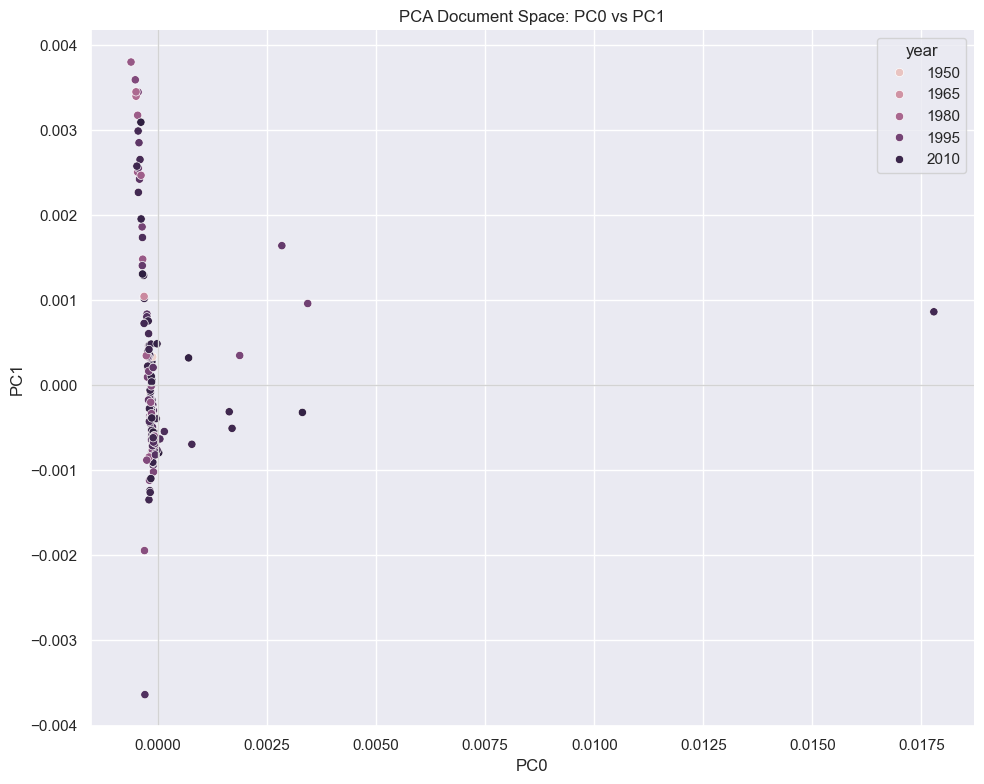

In [39]:
DCMX = DCM.join(DOC[['country', 'year', 'unit_scheme']])
__import__('pathlib').Path('Plot images').mkdir(exist_ok=True)
fig, ax = plt.subplots(figsize=(10, 8))
sns.scatterplot(data=DCMX.reset_index(), x='PC0', y='PC1', hue='year', ax=ax)
ax.axhline(0, c='lightgray', lw=1)
ax.axvline(0, c='lightgray', lw=1)
ax.set_title('PCA Document Space: PC0 vs PC1')
sns.despine()
fig.tight_layout()
fig.savefig('Plot images/pca_vis1_docs.png', dpi=160, bbox_inches='tight')
plt.show()


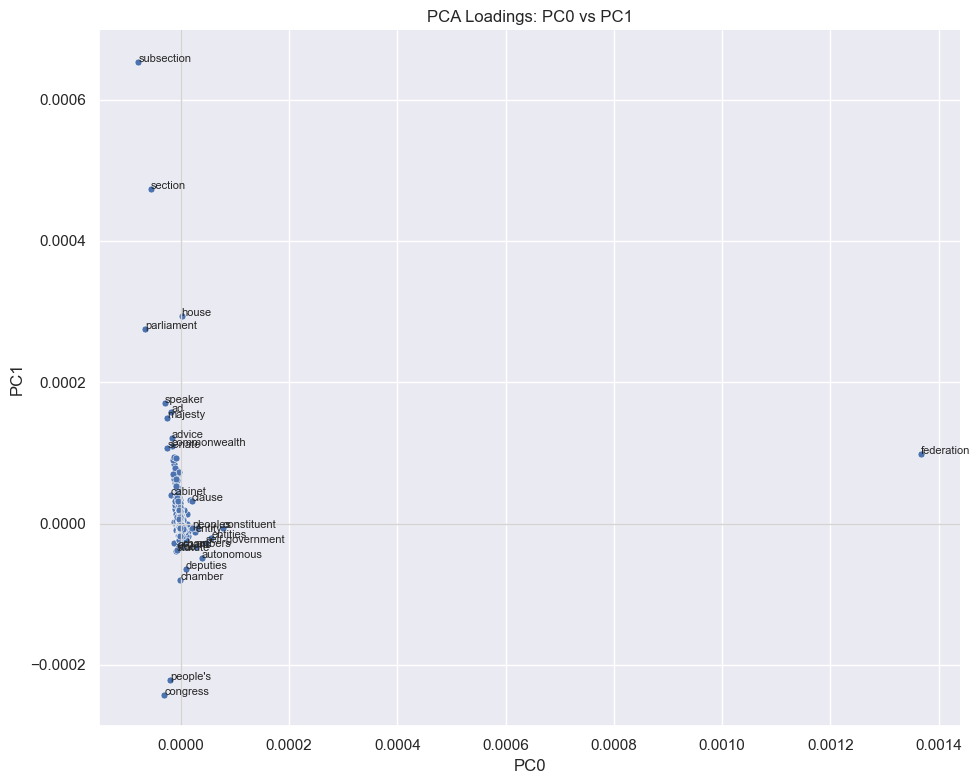

In [40]:
__import__('pathlib').Path('Plot images').mkdir(exist_ok=True)
loadings_plot = LOADINGS.reset_index()
fig, ax = plt.subplots(figsize=(10, 8))
sns.scatterplot(data=loadings_plot, x='PC0', y='PC1', ax=ax, s=25)
label_terms = pd.concat([
    loadings_plot.nlargest(10, 'PC0'),
    loadings_plot.nsmallest(10, 'PC0'),
    loadings_plot.nlargest(10, 'PC1'),
    loadings_plot.nsmallest(10, 'PC1')
]).drop_duplicates('term_str')
for _, row in label_terms.iterrows():
    ax.text(row.PC0, row.PC1, row.term_str, fontsize=8)
ax.axhline(0, c='lightgray', lw=1)
ax.axvline(0, c='lightgray', lw=1)
ax.set_title('PCA Loadings: PC0 vs PC1')
sns.despine()
fig.tight_layout()
fig.savefig('Plot images/pca_vis1_loadings.png', dpi=160, bbox_inches='tight')
plt.show()


## PCA Visualization 2 (4)

Include a scatterplot of documents in the space created by the second two components.

Color the points based on a metadata feature associated with the documents.

Also include a scatterplot of the loadings for the same two components. (This does not need a feature mapped onto color.)

![](Plot%20images/pca_vis2_docs.png)

![](Plot%20images/pca_vis2_loadings.png)

Briefly describe the nature of the polarity you see in the second component:

The second PCA view again is driven by outlying terms rather than a broad, even separation of the corpus. On PC2, the positive side is pulled toward representative or popular-government terms such as “people’s” and “congress,” while many other institutional terms remain clustered near zero. Overall, its difficult to do concrete analysis, as the PCA seems to identify differences in the way governmental sctructures are called, as opposed to any actual content differences.

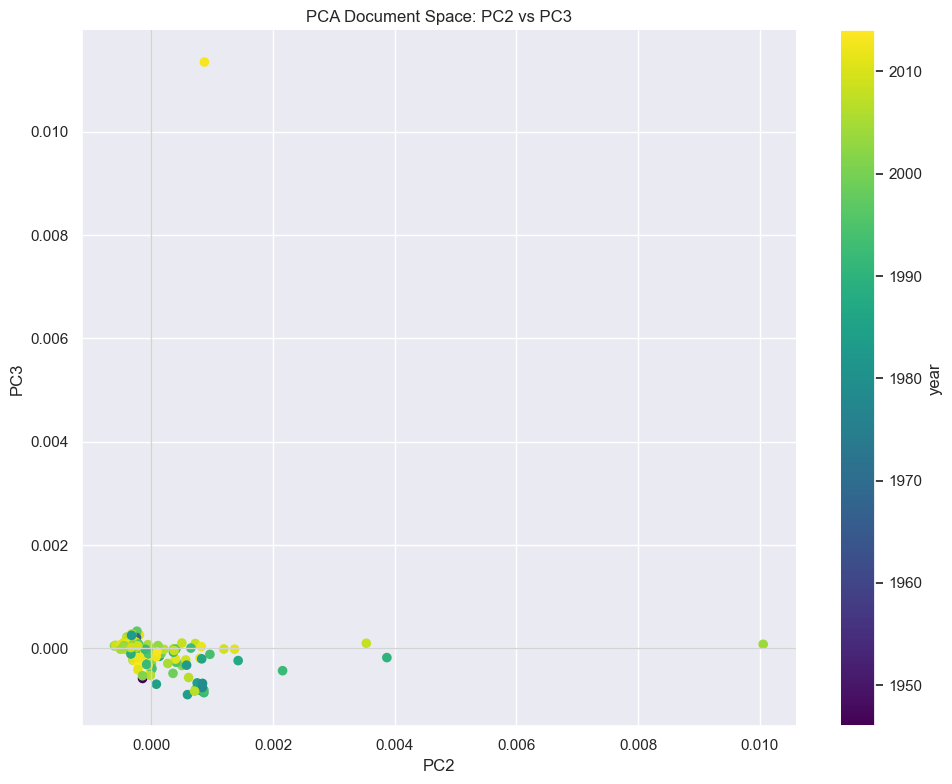

In [41]:
__import__('pathlib').Path('Plot images').mkdir(exist_ok=True)
fig, ax = plt.subplots(figsize=(10, 8))
plot_data = DCMX.reset_index()
points = ax.scatter(plot_data['PC2'], plot_data['PC3'], c=plot_data['year'], cmap='viridis', s=35)
ax.axhline(0, c='lightgray', lw=1)
ax.axvline(0, c='lightgray', lw=1)
ax.set_title('PCA Document Space: PC2 vs PC3')
ax.set_xlabel('PC2')
ax.set_ylabel('PC3')
fig.colorbar(points, ax=ax, label='year')
sns.despine()
fig.tight_layout()
fig.savefig('Plot images/pca_vis2_docs.png', dpi=160, bbox_inches='tight')
plt.show()


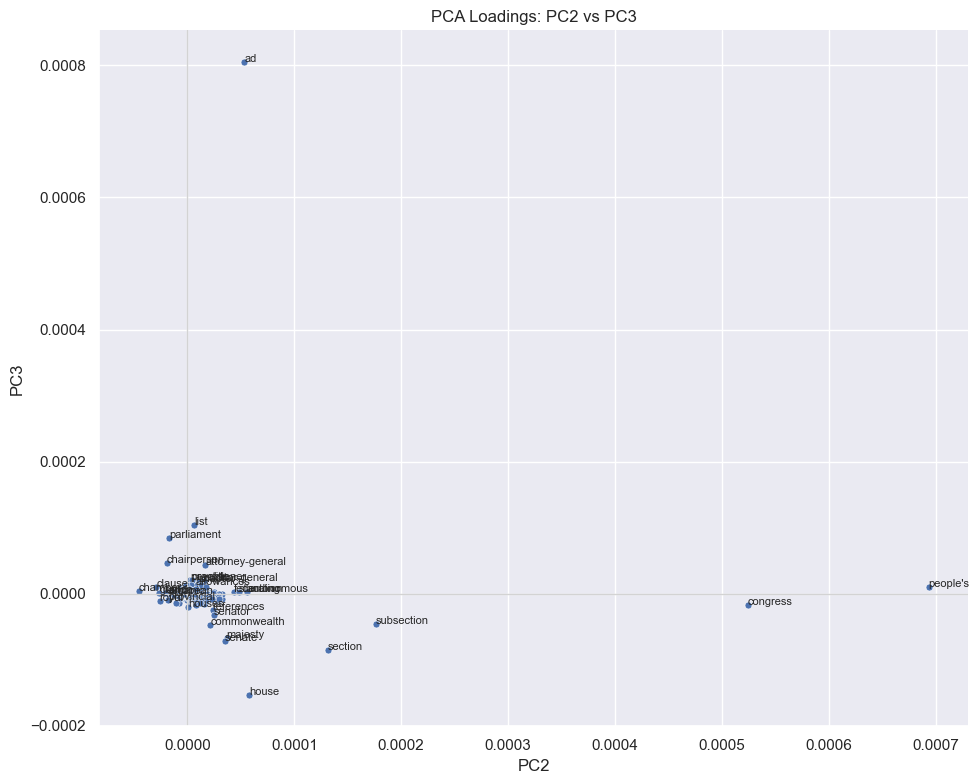

In [42]:
__import__('pathlib').Path('Plot images').mkdir(exist_ok=True)
loadings_plot = LOADINGS.reset_index()
fig, ax = plt.subplots(figsize=(10, 8))
sns.scatterplot(data=loadings_plot, x='PC2', y='PC3', ax=ax, s=25)
label_terms = pd.concat([
    loadings_plot.nlargest(10, 'PC2'),
    loadings_plot.nsmallest(10, 'PC2'),
    loadings_plot.nlargest(10, 'PC3'),
    loadings_plot.nsmallest(10, 'PC3')
]).drop_duplicates('term_str')
for _, row in label_terms.iterrows():
    ax.text(row.PC2, row.PC3, row.term_str, fontsize=8)
ax.axhline(0, c='lightgray', lw=1)
ax.axvline(0, c='lightgray', lw=1)
ax.set_title('PCA Loadings: PC2 vs PC3')
sns.despine()
fig.tight_layout()
fig.savefig('Plot images/pca_vis2_loadings.png', dpi=160, bbox_inches='tight')


## LDA TOPIC (4)

- UVA Box URL:
- UVA Box URL of count matrix used to create: see above
- GitHub URL for notebook used to create:
- Delimitter: comma
- Libary used to compute: `sklearn.decomposition.LatentDirichletAllocation`
- A description of any filtering, e.g. POS (Nouns and Verbs only): nouns only, using `CORPUS.pos.str.match(r'^NNS?$')`; `CountVectorizer` uses English stop words plus `yes`, `max_features=2000`, `max_df=.9`, and `min_df=10`
- Number of components: 20
- Any other parameters used: `max_iter=20`, `random_state=42`, `n_top_terms=9`
- Top 5 words and best-guess labels for top five topics by mean document weight: see generated `TOPICS.top_terms` rows below
  - T15: Judicial Actors -	local|court|bodies|deputies|freedoms|judges
  - T14: Judicial Structure  - section|subsection|court|proceedings|advice
  - T12: Territorial Definition - organic|organization|mandate|territory|matter
  - T13: Government Agencies - development|services|country|promote|entities
  - T03: Congressional Words - statute request membership draft regulations

CSV output: [tables/TOPICS.csv](tables/TOPICS.csv)


In [43]:
model_type = 'lda'
BAG = OHCO[:1]
DOCS = CORPUS[CORPUS.pos.str.match(r'^NNS?$')].reset_index()    .groupby(BAG).term_str    .apply(lambda x: ' '.join(map(str,x)))    .to_frame()    .rename(columns={'term_str':'doc_str'}).join(LIB[['country', 'year', 'unit_scheme']])

my_stop_words = list(text.ENGLISH_STOP_WORDS.union(['yes']))
count_engine = CountVectorizer(max_features=2000, max_df=.9, min_df=10, stop_words=my_stop_words)
count_model = count_engine.fit_transform(DOCS.doc_str)
TERMS = count_engine.get_feature_names_out()
LDA_VOCAB = pd.DataFrame(index=TERMS)
LDA_VOCAB.index.name = 'term_str'
LDA_DTM = count_model

n_topics = 20
max_iter = 20
n_top_terms = 9
TNAMES = [f"T{str(x).zfill(len(str(n_topics)))}" for x in range(n_topics)]
colors = "YlGnBu"

topic_engine = LDA(n_components=n_topics, max_iter=max_iter, random_state=42)
topic_model = topic_engine.fit_transform(count_model)

THETA = pd.DataFrame(topic_model, index=DOCS.index, columns=TNAMES)
THETA.columns.name = 'topic_id'

PHI = pd.DataFrame(topic_engine.components_, columns=TERMS, index=TNAMES)
PHI.index.name = 'topic_id'
PHI.columns.name = 'term_str'

TOPICS = PHI.stack().groupby('topic_id')    .apply(lambda x: ' '.join(x.sort_values(ascending=False).head(n_top_terms).reset_index().term_str))    .to_frame('top_terms')
TOPICS['doc_weight_sum'] = THETA.sum()
TOPICS['term_freq'] = PHI.sum(1) / PHI.sum(1).sum()
TOPICS.sort_values('doc_weight_sum', ascending=False).style.background_gradient(cmap='YlGnBu', axis=0)


,top_terms,doc_weight_sum,term_freq
topic_id,,,
T15,local court bodies deputies freedoms judges constitutional acts basis,34.068128,0.111966
T14,section subsection court proceedings advice question provision purpose purposes,24.495823,0.185871
T12,organic organization mandate territory matter determines establishes territorial regime,22.296912,0.064469
T13,development services country promote entities guarantee cultural activities participation,21.622834,0.136880
T03,statute request membership draft regulations determine absolute budget amendment,20.417863,0.059407
T08,clause paragraph provision thereof purposes court commencement expenditure relation,11.506770,0.088991
T04,list court candidate pursuant written perform hold declaration purpose,9.191573,0.050500
T02,county legislation financial pursuant promote competence local ensure development,8.902820,0.052830
T11,paragraph matter laid provision committee information court offence proposal,5.717332,0.035606


## LDA THETA (4)

- UVA Box URL:
- GitHub URL for notebook used to create:
- Delimitter: comma

CSV output: [tables/THETA.csv](tables/THETA.csv)


In [44]:
THETA


topic_id,T00,T01,T02,T03,T04,T05,T06,T07,T08,T09,T10,T11,T12,T13,T14,T15,T16,T17,T18,T19
doc,,,,,,,,,,,,,,,,,,,,
Afghanistan_2004,0.000032,0.000032,0.000032,0.230980,0.000032,0.022920,0.000032,0.000032,0.000032,0.000032,0.000032,0.000032,0.000032,0.164169,0.000032,0.425901,0.085154,0.017773,0.052693,0.000032
Albania_2008,0.000021,0.039726,0.000021,0.050913,0.000021,0.000021,0.000021,0.000021,0.000021,0.000021,0.060685,0.031425,0.050107,0.036244,0.000021,0.730632,0.000021,0.000021,0.000021,0.000021
Algeria_2008,0.000031,0.000031,0.000031,0.293558,0.000031,0.000031,0.000031,0.000031,0.000031,0.000031,0.000031,0.000031,0.402616,0.092314,0.000031,0.211009,0.000031,0.000031,0.000031,0.000031
Andorra_1993,0.010241,0.000038,0.000038,0.279559,0.000038,0.000038,0.000038,0.000038,0.000038,0.000038,0.085187,0.000038,0.169773,0.133563,0.000038,0.186286,0.000038,0.070143,0.000038,0.064793
Angola_2010,0.004515,0.000011,0.000011,0.041223,0.000011,0.000011,0.000011,0.000011,0.000011,0.000011,0.000011,0.000011,0.046818,0.373637,0.000011,0.176410,0.009008,0.000011,0.039209,0.309048
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
Vanuatu_1983,0.000044,0.000044,0.000044,0.217318,0.295731,0.000044,0.000044,0.023013,0.000044,0.000044,0.032312,0.078865,0.000044,0.000044,0.205046,0.000044,0.104144,0.000044,0.043037,0.000044
Venezuela_2009,0.036602,0.006266,0.038724,0.033050,0.020782,0.000007,0.000007,0.000007,0.000007,0.000007,0.011731,0.000007,0.029999,0.788708,0.002355,0.027713,0.000007,0.002039,0.001975,0.000007
Yemen_2001,0.000027,0.000027,0.090437,0.444915,0.002388,0.000027,0.000027,0.000027,0.000027,0.000027,0.021063,0.005992,0.000027,0.189918,0.000027,0.244936,0.000027,0.000027,0.000027,0.000027


## LDA PHI (4)

- UVA Box URL:
- GitHub URL for notebook used to create:
- Delimitter: comma

CSV output: [tables/PHI.csv](tables/PHI.csv)


In [45]:
PHI


term_str,abide,ability,able,abolish,abolition,abroad,absence,absent,absolute,abuse,...,works,world,worship,writ,writs,written,young,youth,zone,zones
topic_id,,,,,,,,,,,,,,,,,,,,,
T00,0.050000,0.050000,5.563802,1.359313,19.125961,36.616026,11.282538,0.050000,46.674140,15.330196,...,42.485441,0.067770,2.628973,7.992038,10.307636,2.305972,11.458444,10.175962,6.966387,1.611611
T01,0.050000,0.050000,0.050000,0.050000,0.050000,0.050000,16.616114,0.050000,116.877864,0.050000,...,0.050000,0.050000,0.050000,1.687934,0.747456,0.050000,0.050000,0.050000,0.050000,13.697987
T02,35.836667,9.122151,6.570490,4.712370,2.963967,8.440704,22.188565,0.050000,0.248884,33.932947,...,4.098209,12.137944,7.435729,0.050000,0.050000,1.187748,0.050000,14.673861,0.050000,0.050000
T03,0.050000,8.838110,4.710616,0.050000,0.050000,5.612238,28.115066,0.050000,257.894843,4.603321,...,0.050000,21.948943,30.187719,0.050000,0.050000,0.050000,16.828143,32.131540,0.050000,0.050000
T04,0.050000,36.522924,14.627671,0.050000,0.050000,17.787560,12.024366,62.261648,0.050000,20.648795,...,0.050000,9.401598,0.050000,33.129162,0.050000,269.124277,0.050000,0.050000,0.050000,0.050000
T05,17.469418,7.658663,9.343901,0.050000,0.050000,19.855008,0.050000,0.050000,0.050000,0.050000,...,18.024425,25.134713,0.050000,0.050000,5.369180,18.245311,0.050000,6.755802,0.050000,1.075231
T06,0.050000,0.050000,0.050000,0.050000,0.050000,0.050000,0.050000,0.050000,0.050000,0.050000,...,0.050000,0.050000,0.050000,0.050000,0.050000,0.050000,0.050000,0.050000,0.050000,0.050000
T07,0.050000,0.050000,0.050000,0.050000,0.050000,0.050000,0.050000,0.050000,0.050000,0.050000,...,0.050000,0.050000,0.050000,0.050000,0.050000,11.375008,0.050000,0.050000,0.050000,0.050000
T08,6.835422,41.425775,0.312411,5.552638,31.972643,0.050000,151.729882,65.945245,2.507868,1.823229,...,23.079550,0.050000,23.741100,6.293947,34.416705,161.005847,0.050000,1.676699,8.198844,3.499272


## LDA + PCA Visualization (4)

Apply PCA to the THETA table and plot the topics in the space opened by the first two components.

Size the points based on the mean document weight of each topic (using the THETA table).

Color the points basd on a metadata feature from the LIB table.

Provide a brief interpretation of what you see.

(INSERT IMAGE HERE)

(INSERT INTERPRETATION HERE)

CSV output: [tables/TCM.csv](tables/TCM.csv)


In [46]:
pca_engine = PCA(n_components=5)
TCM = pd.DataFrame(pca_engine.fit_transform(THETA.T), index=THETA.T.index)
TCM


,0,1,2,3,4
topic_id,,,,,
T00,-0.163056,-0.219526,-0.391023,-0.126953,-0.148848
T01,-0.123871,-0.202610,-0.339672,-0.066021,-0.170094
T02,-0.039068,-0.080582,-0.423293,-0.162445,0.183533
T03,0.618083,-0.113376,0.041167,0.236007,2.318320
T04,-0.283775,0.094491,-0.266616,-0.208843,0.116293
T05,-0.058209,-0.145066,-0.382167,-0.074488,-0.215244
T06,-0.200635,-0.195190,-0.373397,-0.218277,-0.181892
T07,-0.210066,-0.191998,-0.403078,-0.206628,-0.173536
T08,-0.526922,0.115830,-0.305033,-0.412372,-0.053437


## Sentiment VOCAB_SENT (4)

Sentiment values associated with a subset of the VOCAB from a curated sentiment lexicon. This table is the NRC sentiment lexicon joined to VOCAB and restricted to terms present in VOCAB.

- UVA Box URL:
- UVA Box URL for source lexicon: see above
- GitHub URL for notebook used to create:
- Delimitter: comma

CSV output: [tables/VOCAB_SENT.csv](tables/VOCAB_SENT.csv)


In [47]:
salex_file = "lexicons/salex_nrc.csv"
emo_cols = "anger anticipation disgust fear joy sadness surprise trust sentiment".split()

SALEX = pd.read_csv(salex_file).set_index('term_str')
SALEX.columns = [col.replace('nrc_','') for col in SALEX.columns]
VOCAB_SENT = VOCAB.join(SALEX, how='inner')
VOCAB_SENT


,n,p,i,h,df,idf,dfidf,n_chars,ngram_length,porter_stem,...,anticipation,disgust,fear,joy,negative,positive,sadness,surprise,trust,sentiment
term_str,,,,,,,,,,,,,,,,,,,,,
abandon,11,2.630529e-06,18.536215,0.000049,11,4.125531,45.380840,7,1,abandon,...,0,0,1,0,1,0,1,0,0,-1
abandoned,37,8.848144e-06,16.786194,0.000149,28,2.777608,77.773012,9,1,abandon,...,0,0,1,0,1,0,1,0,0,-1
abandonment,43,1.028298e-05,16.569382,0.000170,34,2.497500,84.914988,11,1,abandon,...,0,0,1,0,1,0,1,1,0,-1
abduction,2,4.782780e-07,20.995647,0.000010,2,6.584963,13.169925,9,1,abduct,...,0,0,1,0,1,0,1,1,0,-1
abhor,1,2.391390e-07,21.995647,0.000005,1,7.584963,7.584963,5,1,abhor,...,0,1,1,0,1,0,0,0,0,-1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
wrongly,4,9.565561e-07,19.995647,0.000019,3,6.000000,18.000000,7,1,wrongli,...,0,0,1,0,1,0,1,0,0,-1
xenophobia,6,1.434834e-06,19.410685,0.000028,5,5.263034,26.315172,10,1,xenophobia,...,0,0,1,0,1,0,0,0,0,-1
young,118,2.821840e-05,15.113004,0.000426,57,1.752072,99.868132,5,1,young,...,1,0,0,1,0,1,0,1,0,1


## Sentiment BOW_SENT (4)

Sentiment values from VOCAB_SENT mapped onto a paragraph-level BOW table. Each lexicon value is multiplied by the count `n` of the term in the bag.

- UVA Box URL:
- GitHub URL for notebook used to create:
- Delimitter: comma

CSV output: [tables/BOW_SENT_WEIGHTED.csv](tables/BOW_SENT_WEIGHTED.csv)


In [48]:
sent_bag = bags['PARAS']
BOW_SENT = BOW_PARA.join(VOCAB_SENT[emo_cols], on='term_str', how='inner')
BOW_SENT[emo_cols] = BOW_SENT[emo_cols].multiply(BOW_SENT.n, axis=0)
BOW_SENT


n  anger  anticipation  \
doc              div1 div2 unit para term_str                              
Afghanistan_2004 0    0    1    1    peace        1      0             1   
                                     praise       2      0             0   
                                3    believing    1      0             0   
                                     god          1      0             1   
                                5    freedom      1      0             0   
...                                              ..    ...           ...   
Zimbabwe_2013    66   0    33   0    effective    1      0             0   
                                     immediately  1      0             1   
                           34   1    effective    1      0             0   
                                     enjoy        1      0             1   
                                     immediately  1      0             1   

                                                  disgust  fear  joy  sadness  \
doc              div1 div2 unit para term_str                                   
Afghanistan_2004 0    0    1    1    peace              0     0    1        0   
                                     praise             0     0    2        0   
                                3    believing          0     0    0        0   
                                     god                0     1    1        0   
                                5    freedom            0     0    1        0   
...                                                   ...   ...  ...      ...   
Zimbabwe_2013    66   0    33   0    effective          0     0    0        0   
                                     immediately        0     0    0        0   
                           34   1    effective          0     0    0        0   
                                     enjoy              0     0    1        0   
                                     immediately        0     0    0        0   

                                                  surprise  trust  sentiment  
doc              div1 div2 unit para term_str                                 
Afghanistan_2004 0    0    1    1    peace               0      1          1  
                                     praise              0      2          2  
                                3    believing           0      1          1  
                                     god                 0      1          1  
                                5    freedom             0      1          1  
...                                                    ...    ...        ...  
Zimbabwe_2013    66   0    33   0    effective           0      1          1  
                                     immediately         0      0          0  
                           34   1    effective           0      1          1  
                                     enjoy               0      1          1  
                                     immediately         0      0          0  

[276024 rows x 10 columns]

## Sentiment DOC_SENT (4)

Computed sentiment per OHCO bag from BOW_SENT by aggregating the count-weighted sentiment values.

- UVA Box URL:
- GitHub URL for notebook used to create:
- Delimitter: comma
- Document bag expressed in terms of OHCO levels: doc|div1|div2|unit|para

CSV output: [tables/DOC_SENT.csv](tables/DOC_SENT.csv)


In [49]:
DOC_SENT = BOW_SENT.groupby(sent_bag)[emo_cols].sum()
DOC_SENT['n'] = BOW_SENT.groupby(sent_bag).n.sum()
DOC_SENT


anger  anticipation  disgust  fear  joy  \
doc              div1 div2 unit para                                            
Afghanistan_2004 0    0    1    1         0             1        0     0    3   
                                3         0             1        0     1    1   
                                5         1             0        1     1    1   
                                6         0             0        0     0    0   
                                7         0             0        0     0    0   
...                                     ...           ...      ...   ...  ...   
Zimbabwe_2013    66   0    30   1         2             0        1     3    0   
                                2         0             0        0     2    0   
                           32   0         1             0        1     1    0   
                           33   0         0             1        0     0    0   
                           34   1         0             2        0     0    1   

                                      sadness  surprise  trust  sentiment  n  
doc              div1 div2 unit para                                          
Afghanistan_2004 0    0    1    1           0         0      3          3  3  
                                3           0         0      2          2  2  
                                5           1         0      1         -1  3  
                                6           0         0      1          1  1  
                                7           0         0      1          1  1  
...                                       ...       ...    ...        ... ..  
Zimbabwe_2013    66   0    30   1           1         0      0         -3  3  
                                2           2         0      0         -2  2  
                           32   0           0         0      1          0  2  
                           33   0           0         0      1          1  2  
                           34   1           0         0      2          2  3  

[116097 rows x 10 columns]

## Sentiment Plot (4)

Plot sentiment over some metric space, such as time.

If you don't have a metric metadata features, plot sentiment over a feature of your choice.

You may use a bar chart or a line graph.

![](Plot%20images/sentiment_plot.png)

CSV output: [tables/DOC_SENT_DOC.csv](tables/DOC_SENT_DOC.csv)


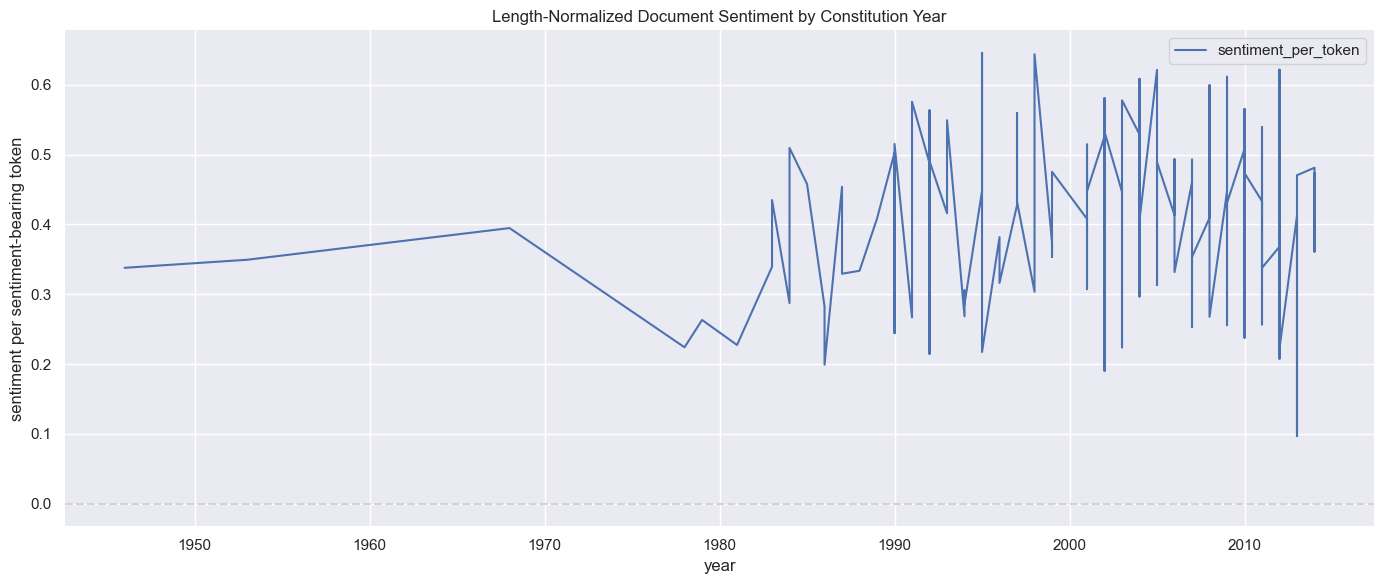

In [50]:
__import__('pathlib').Path('Plot images').mkdir(exist_ok=True)
DOC_SENT_DOC = DOC_SENT.groupby('doc')[emo_cols + ['n']].sum().join(LIB[['country', 'year', 'unit_scheme']])
DOC_SENT_DOC['sentiment_per_token'] = DOC_SENT_DOC['sentiment'] / DOC_SENT_DOC['n']
ax = DOC_SENT_DOC.sort_values('year').set_index('year')[['sentiment_per_token']].plot(figsize=(14,6))
ax.axhline(0, c='lightgray', ls='--')
ax.set_title('Length-Normalized Document Sentiment by Constitution Year')
ax.set_ylabel('sentiment per sentiment-bearing token')
sns.despine(left=True, bottom=True)
fig = ax.get_figure()
fig.tight_layout()
fig.savefig('Plot images/sentiment_plot.png', dpi=160, bbox_inches='tight')
plt.show()


## VOCAB_W2V (4)

A table of word2vec features associated with terms in the VOCAB table.

- UVA Box URL:
- GitHub URL for notebook used to create:
- Delimitter: comma
- Document bag expressed in terms of OHCO levels: doc|div1|div2|unit
- Number of features generated: 256
- The library used to generate the embeddings: `gensim.models.word2vec.Word2Vec`

CSV output: [tables/VOCAB_W2V.csv](tables/VOCAB_W2V.csv)


In [51]:
BAG = OHCO[:4]
docs = CORPUS.reset_index().groupby(BAG).term_str.apply(list).to_list()

w2v_params = dict(
    window = 2,
    vector_size = 256,
    min_count = 50,
    workers = 1,
    seed = 42
)

model = word2vec.Word2Vec(docs, **w2v_params)
VOCAB_W2V = pd.DataFrame(model.wv.vectors, index=model.wv.index_to_key)
VOCAB_W2V.index.name = 'term_str'
VOCAB_W2V


Exception ignored in: 'gensim.models.word2vec_inner.our_dot_float'
Exception ignored in: 'gensim.models.word2vec_inner.our_dot_float'


,0,1,2,3,4,5,6,7,8,9,...,246,247,248,249,250,251,252,253,254,255
term_str,,,,,,,,,,,,,,,,,,,,,
the,-0.770766,0.078057,0.110454,0.262104,-0.344130,0.469815,-0.190232,-0.514892,0.531457,-0.498796,...,-0.277476,-0.383965,0.852325,0.085168,0.185766,0.031066,0.284749,0.099180,0.044625,-0.013625
of,-0.724667,-0.457570,-0.149014,0.343414,0.136545,-0.262511,-0.663874,0.610226,0.293779,0.002127,...,0.182173,0.247937,0.725238,0.383124,0.599052,-0.389032,-0.796459,-0.198257,0.520805,0.067254
and,0.415943,-0.665090,0.474346,-0.338420,0.542257,0.364818,0.129568,0.084177,0.387997,-0.341668,...,1.246830,0.273634,-0.094887,0.111527,0.118652,0.677130,0.112362,-0.243188,-0.124247,0.113134
to,0.019660,-0.261477,0.774296,0.746548,-0.432916,-0.584707,0.141866,0.780243,0.091373,-0.376727,...,-0.253974,0.333807,-0.028117,1.118772,0.191250,-0.499955,-0.495716,-0.163626,0.592265,-0.083756
in,0.506802,0.067948,-0.313770,0.271053,-0.352249,-0.357865,0.347671,-0.140514,0.973076,0.168237,...,-0.575170,-0.628690,0.708804,1.459189,0.317977,0.312649,0.404817,-0.098390,-1.051071,0.179351
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
partisan,-0.029055,-0.134306,0.028877,0.112601,-0.043447,0.209662,0.160463,-0.017849,0.059200,-0.151464,...,-0.342106,-0.016979,-0.186153,0.055599,-0.123138,-0.004382,-0.133458,0.228111,-0.078943,0.259705
running,0.023667,-0.133505,0.089249,0.011332,-0.046295,-0.077795,0.024212,0.074084,-0.038066,-0.084761,...,0.055714,-0.119664,-0.004521,0.023430,0.226353,-0.186918,0.016301,0.033295,0.023221,-0.000620
truth,0.110306,0.043528,-0.097168,-0.101234,-0.187976,0.114635,0.120949,0.075930,0.085392,-0.139714,...,0.065598,-0.097025,-0.166176,0.061262,0.023896,-0.157109,0.014852,0.136316,-0.013026,0.131597


## Word2vec tSNE Plot (4)

Plot word embedding featues in two-dimensions using t-SNE.

Describe a cluster in the plot that captures your attention.

![](Plot%20images/word2vec_tsne.png)

Looking at the plot, only two clusters catch my attention. The first, is the section between 0 and 20 on the X axis, and -80 and -55 on the Y-axis. After researching that cluster, I identified that this cluster was exclusively numbers and organizational words, like sub-section and article. The other semi-identifiable cluster was the words in between -50 and -30 on the x axis, and -55 and -30 on the y axis. These words all encompassed past tense verbs, which in this corpus were mostly legal verbs.

CSV output: [tables/TSNE.csv](tables/TSNE.csv), [Plot images/word2vec_tsne_selected_clusters.csv](Plot%20images/word2vec_tsne_selected_clusters.csv)


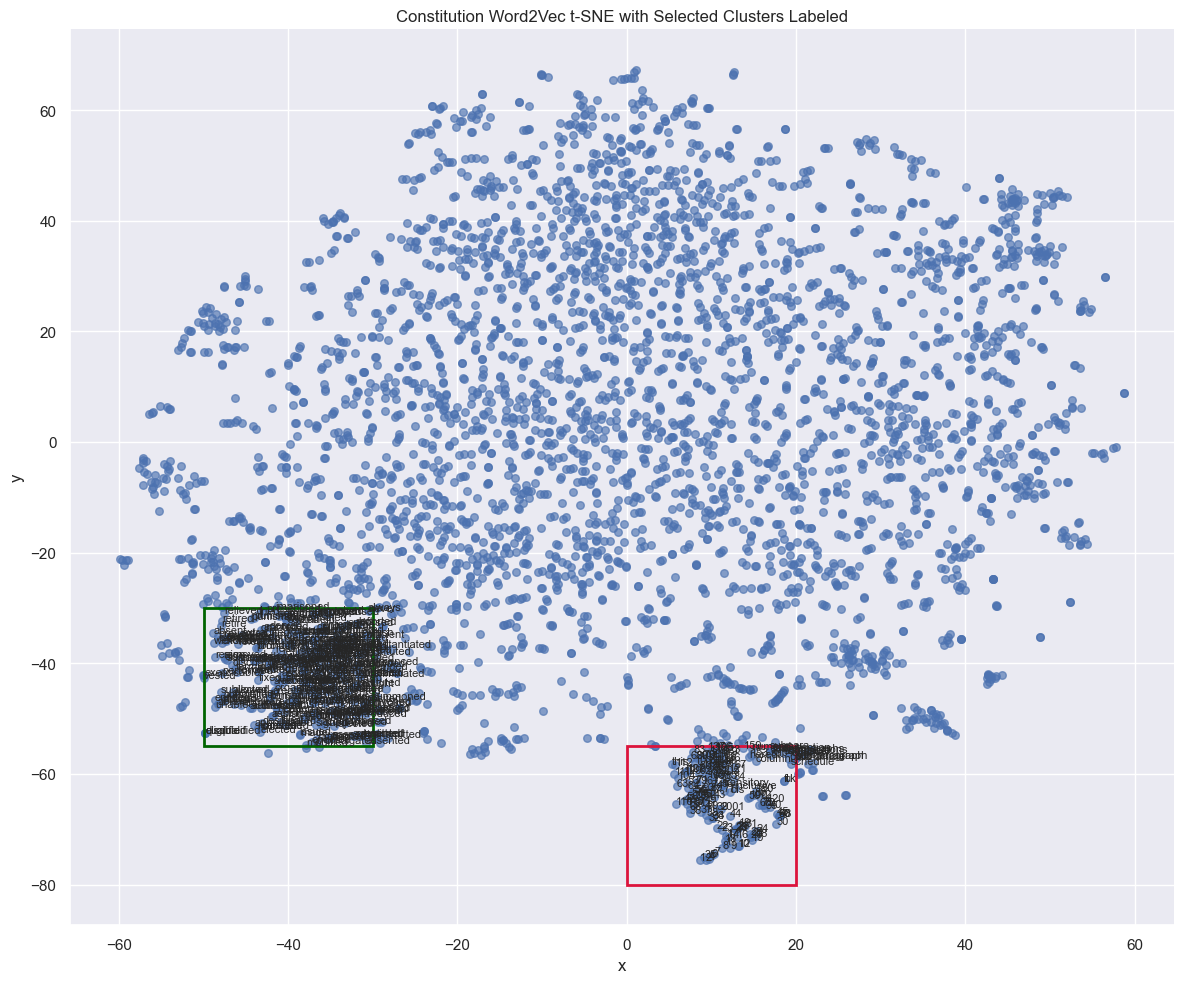

,cluster,term_str,x,y
5,"x -50 to -30, y -55 to -30",a,-31.273453,-38.284729
2593,"x -50 to -30, y -55 to -30",abide,-39.416737,-46.359104
1224,"x -50 to -30, y -55 to -30",able,-48.291203,-47.289112
2678,"x -50 to -30, y -55 to -30",abolished,-38.575565,-38.159302
1032,"x -50 to -30, y -55 to -30",absent,-48.842999,-34.614944
...,...,...,...,...
3492,"x 0 to 20, y -80 to -55",subparagraphs,16.954609,-55.855274
1347,"x 0 to 20, y -80 to -55",subsections,19.298304,-56.110302
18,"x 0 to 20, y -80 to -55",this,5.364798,-58.129379
1976,"x 0 to 20, y -80 to -55",transitory,11.413417,-61.994102


In [56]:
__import__('pathlib').Path('Plot images').mkdir(exist_ok=True)
from matplotlib.patches import Rectangle

PP = 20

tsne_engine = tsne(
    perplexity=PP,
    n_components=2,
    init='pca',
    max_iter=1000,
    random_state=42
)
TSNE = pd.DataFrame(
    tsne_engine.fit_transform(VOCAB_W2V),
    columns=['x','y'],
    index=VOCAB_W2V.index)

plot_data = TSNE.reset_index().rename(columns={'index': 'term_str'})
cluster_a = plot_data[plot_data.x.between(0, 20) & plot_data.y.between(-80, -55)].copy()
cluster_b = plot_data[plot_data.x.between(-50, -30) & plot_data.y.between(-55, -30)].copy()
cluster_a['cluster'] = 'x 0 to 20, y -80 to -55'
cluster_b['cluster'] = 'x -50 to -30, y -55 to -30'
TSNE_CLUSTERS = pd.concat([cluster_a, cluster_b]).sort_values(['cluster', 'term_str'])
TSNE_CLUSTERS.to_csv('Plot images/word2vec_tsne_selected_clusters.csv', index=False)

fig, ax = plt.subplots(figsize=(12, 10))
scatter = ax.scatter(plot_data.x, plot_data.y, s=30, alpha=.65)
ax.add_patch(Rectangle((0, -80), 20, 25, fill=False, edgecolor='crimson', lw=2))
ax.add_patch(Rectangle((-50, -55), 20, 25, fill=False, edgecolor='darkgreen', lw=2))
for _, row in TSNE_CLUSTERS.iterrows():
    ax.text(row['x'], row['y'], row.term_str, fontsize=8)
annot = ax.annotate('', xy=(0, 0), xytext=(12, 12), textcoords='offset points',
                    bbox=dict(boxstyle='round', fc='white', alpha=.85),
                    arrowprops=dict(arrowstyle='->'))
annot.set_visible(False)

def update_annot(ind):
    idx = ind['ind'][0]
    annot.xy = scatter.get_offsets()[idx]
    annot.set_text(plot_data.iloc[idx].term_str)

def hover(event):
    visible = annot.get_visible()
    if event.inaxes == ax:
        contains, ind = scatter.contains(event)
        if contains:
            update_annot(ind)
            annot.set_visible(True)
            fig.canvas.draw_idle()
        elif visible:
            annot.set_visible(False)
            fig.canvas.draw_idle()

fig.canvas.mpl_connect('motion_notify_event', hover)
ax.set_title('Constitution Word2Vec t-SNE with Selected Clusters Labeled')
ax.set_xlabel('x')
ax.set_ylabel('y')
sns.despine()
fig.tight_layout()
fig.savefig('Plot images/word2vec_tsne.png', dpi=160, bbox_inches='tight')
plt.show()
TSNE_CLUSTERS[['cluster', 'term_str', 'x', 'y']]
